In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP, NetCNN2D_CSP_GAP, build_functional_cnn2D

from mne.decoding import CSP

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle
import tqdm, logging, warnings

import train_evaluate

from quantizeml.models import QuantizationParams, quantize
import akida
from cnn2snn import convert, set_akida_version, AkidaVersion



# Filter out info and warnings from TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')


config = Config()

config.model_type = '2D'


# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CUp'], ['CDown']]
config.session_type = 'S2'




config.test_session = 11


config.t_start = 0 
config.t_end = 3.0

if config.model_type == '2D':
    config.window_size = 1.0
elif config.model_type == '2D_GAP':
    config.window_size = 2.0




config.n_csp_components = 3


# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']





################# Changed in Adaptation #################

config.stride = 1.0


config.epochs = 5
config.batch_size = 64


config.learning_rate = 1e-4
config.label_smoothing = 0.05
config.weight_decay = 2e-5

model = NetCNN2D_CSP(len(config.used_classes))
model.build((32, 3, 500, 1))
model.summary()


Model: "net_cnn2d_csp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 cnn1 (Sequential)           (32, 1, 167, 8)           432       
                                                                 
 cnn2 (Sequential)           (32, 1, 84, 16)           1232      
                                                                 
 cnn2 (Sequential)           (32, 1, 42, 16)           2384      
                                                                 
 fc (Sequential)             (32, 2)                   86402     
                                                                 
Total params: 90450 (353.32 KB)
Trainable params: 90370 (353.01 KB)
Non-trainable params: 80 (320.00 Byte)
_________________________________________________________________


In [2]:
X, y = [], []
for i in range(1, 12):
    if i == config.test_session:
        continue
    Xi, yi = dataset_NewEEG.session_dataset(config, f'I{i:02d}')
    X.append(Xi)
    y.append(yi)


X, y = np.concatenate(X), np.concatenate(y)

print(X.shape)
print(y.shape)

shuffle_indices = np.random.permutation(len(y))
X_train, Y_train = X[shuffle_indices], y[shuffle_indices]


X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
shuffle_indices = np.random.permutation(len(y))
X_valid, Y_valid = X[shuffle_indices], y[shuffle_indices]


(320, 13, 750)
(320,)


Epoch 1/5
15/15 [==============================] - 7s 281ms/step - loss: 0.7423 - acc: 0.5365 - val_loss: 0.6785 - val_acc: 0.5679
Epoch 2/5
15/15 [==============================] - 3s 202ms/step - loss: 0.7104 - acc: 0.5479 - val_loss: 0.6816 - val_acc: 0.5185
Epoch 3/5
15/15 [==============================] - 3s 204ms/step - loss: 0.6970 - acc: 0.5833 - val_loss: 0.6831 - val_acc: 0.5432
Epoch 4/5
15/15 [==============================] - 3s 199ms/step - loss: 0.6846 - acc: 0.5844 - val_loss: 0.6847 - val_acc: 0.5185
Epoch 5/5
15/15 [==============================] - 3s 229ms/step - loss: 0.6793 - acc: 0.5885 - val_loss: 0.6877 - val_acc: 0.4938


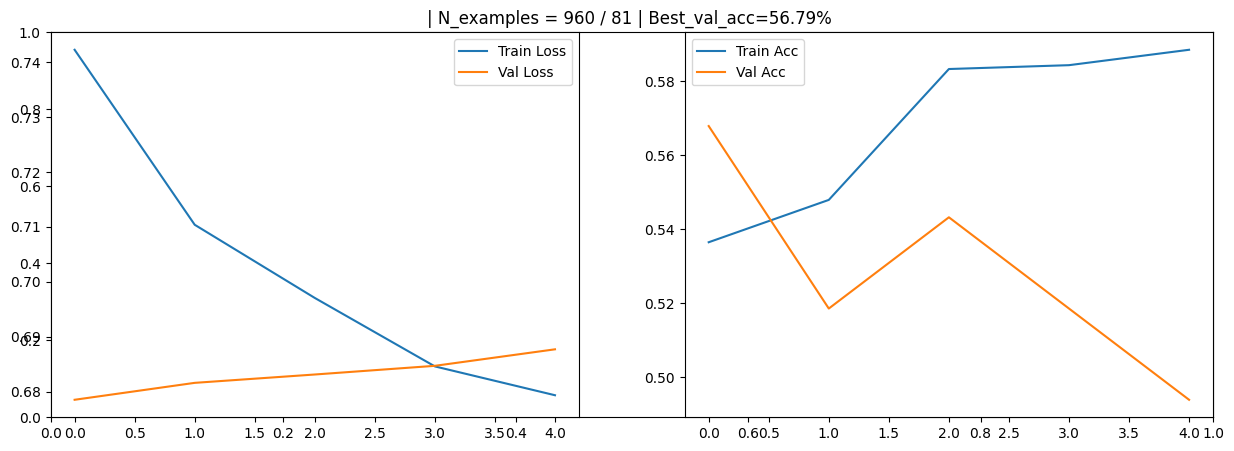

In [3]:
if config.model_type == '2D':
    model = NetCNN2D_CSP(len(config.used_classes))

    model, csp, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, choose_on='acc', plot_graphs=True)


elif config.model_type == '2D_GAP':
    model = NetCNN2D_CSP_GAP(len(config.used_classes))

    model, csp, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, choose_on='val_acc', plot_graphs=True)


    naming = config.used_classes[0][0][1] + config.used_classes[1][0][1] + '_gap'

    model.save(os.path.join('saved_models', naming+'.tf'), save_format='tf')
    print(f"Best model saved  with validation accuracy: {val_acc:.4f}")

    with open(os.path.join('saved_models','csp'+naming+'.pkl'), 'wb') as f:
        pickle.dump(csp, f)

else:
    model = NetCNN1D(len(config.used_classes))

In [4]:
if config.model_type == '2D':


    X_train, _ = dataset_NewEEG.slice_EEG_epoch(config, X_train, Y_train)
    X_valid, Y_valid = dataset_NewEEG.slice_EEG_epoch(config, X_valid, Y_valid)

    X_train = csp.transform(X_train)
    X_valid = csp.transform(X_valid)

    X_train = np.expand_dims(X_train, 3)
    X_valid = np.expand_dims(X_valid, 3)

    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = len(config.used_classes))


    Xq = ((X_train - X_train.min()) / (X_train.max() - X_train.min()) * 255).astype(np.uint8)
    Xqv = ((X_valid - X_valid.min()) / (X_valid.max() - X_valid.min()) * 255).astype(np.uint8)


    Xq = np.pad(Xq, ((0, 0), (2, 2), (0, 0), (0, 0)), mode='constant', constant_values=0)
    Xqv = np.pad(Xqv,  ((0, 0), (2, 2), (0, 0), (0, 0)), mode='constant', constant_values=0)


    functional_model = build_functional_cnn2D(n_classes=2, input_shape=(7, 250, 1))
    functional_model.set_weights(model.get_weights())


    qparams = QuantizationParams(input_weight_bits=8, weight_bits=4, activation_bits=4, per_tensor_activations=True)
    quantized_model = quantize(functional_model, qparams=qparams, samples=Xq, num_samples=300, batch_size=64, epochs=10)
    quantized_model.summary()



    quantized_model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=config.label_smoothing),
            optimizer=keras.optimizers.Adam(learning_rate=config.learning_rate, weight_decay = config.weight_decay), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 

    loss, acc = quantized_model.evaluate(Xqv, Y_valid)
    print("Quantized model validation acc = ", acc)




    with set_akida_version(AkidaVersion.v1):
        model_akida = convert(quantized_model)
        print()
        model_akida.summary()




    naming = config.used_classes[0][0][1] + config.used_classes[1][0][1]

    model.save(os.path.join('saved_models',naming+'.tf'), save_format='tf')

    with open(os.path.join('saved_models','csp' +naming+ '.pkl'), 'wb') as f:
        pickle.dump(csp, f)

    model_akida.save(os.path.join('saved_models', naming+'.fbz'))

5/5 [==============================] - 0s 4ms/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 7, 250, 1)]       0         
                                                                 
 conv2d_6 (QuantizedConv2D)  (None, 3, 84, 8)          400       
                                                                 
 re_lu_8 (QuantizedReLU)     (None, 3, 84, 8)          2         
                                                                 
 conv2d_7 (QuantizedConv2D)  (None, 2, 42, 16)         1168      
                                                                 
 re_lu_9 (QuantizedReLU)     (None, 2, 42, 16)         2         
                                                                 
 conv2d_8 (QuantizedConv2D)  (None, 1, 21, 16)         2320      
                                                                 
 re_lu_10 

In [5]:
functional_model = build_functional_cnn2D(n_classes=2, input_shape=(7, 250, 1))
functional_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 7, 250, 1)]       0         
                                                                 
 conv2d_9 (Conv2D)           (None, 3, 84, 8)          400       
                                                                 
 batch_normalization_9 (Bat  (None, 3, 84, 8)          32        
 chNormalization)                                                
                                                                 
 re_lu_12 (ReLU)             (None, 3, 84, 8)          0         
                                                                 
 conv2d_10 (Conv2D)          (None, 2, 42, 16)         1168      
                                                                 
 batch_normalization_10 (Ba  (None, 2, 42, 16)         64        
 tchNormalization)                                         

In [6]:
import numpy as np

# Create your original (3, 500) array. For illustration, we'll use random values.
original_array  = np.random.randint(0, 100, (3, 20))#.astype(np.uint8)

# Pad the array: ((pad_before, pad_after), (pad_left, pad_right))
# Here, pad the first dimension by 4 on each side and do not pad the second dimension.
padded_array = np.pad(original_array, ((4, 4), (0, 0)), mode='constant', constant_values=0)

print("Original shape:", original_array.shape)  # Output: (3, 500)
print("Padded shape:", padded_array.shape)        # Output: (11, 500)

Original shape: (3, 20)
Padded shape: (11, 20)


In [7]:
padded_array

array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 5, 13, 28, 42, 39,  6, 35, 69, 54, 76, 81, 33, 59, 82, 36, 99,
        53, 71, 20, 80],
       [74, 42, 91, 23, 61, 21, 37, 14, 86, 62, 90, 99, 63, 91, 57, 90,
        34, 27, 45, 54],
       [82, 83, 95, 35, 76, 50, 56, 44, 98, 43, 45, 47, 47, 37,  1, 89,
        55, 74, 21, 25],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0

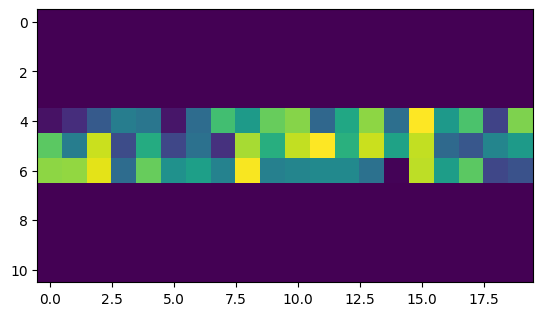

In [8]:
plt.imshow(padded_array)